# Preliminary Geometry-Based Assessment of Building-Induced Beam Blockage on Tangerang C-Band Weather Radar

**Penulis:** Tim Penelitian Radar Tangerang  
**Metode:** Obstruction Angle Geometry  
**Studi Kasus:** Radar C-Band Stasiun Geofisika Tangerang

---

## Ringkasan Metodologi

Notebook ini menghitung **sudut halangan (obstruction angle)** bangunan terhadap radar,  
membandingkannya dengan **amplop beam pada 9 elevasi scan VCP-style**,  
dan mengklasifikasikan potensi blockage menjadi:

| Kelas | Kondisi |
|-------|---------|
| 🟢 **Clear**   | α < θ_lower  |
| 🟡 **Partial** | θ_lower ≤ α ≤ θ_upper |
| 🔴 **Severe**  | α > θ_upper  |

**Batasan penting:**
- Bukan fraksi partial beam blockage (wradlib-style)  
- Tidak menggunakan DEM/DSM  
- Tinggi radar = top-of-radome, bukan antenna phase center  
- Elevasi scan = referensi VCP 21-style, bukan konfirmasi operasional Tangerang


In [1]:
# ============================================================
# CELL 1 — Import & Parameter Kunci
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import matplotlib.ticker as mticker
import os
import warnings
warnings.filterwarnings("ignore")

# ── Output directories ────────────────────────────────────────────────────────
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/tables",  exist_ok=True)

# ── Parameter Kunci ───────────────────────────────────────────────────────────
# (sumber: tabel spesifikasi di README)

H_RADAR    = 21.0   # Tinggi radar / top-of-radome (m)     | Operator
H_BUILDING = 39.0   # Tinggi bangunan (m)                   | WIKA Gedung
BEAMWIDTH  = 0.95   # Beam width -3 dB (°)                  | EEC datasheet

# Tiga skenario jarak gedung (m) berdasarkan pengukuran Google Earth Pro
D_MIN    = 44.6     # Jarak terdekat
D_CENTER = 96.5     # Jarak representatif / center footprint
D_MAX    = 154.0    # Jarak terjauh

DISTANCES = {"D_min (44.6 m)":    D_MIN,
             "D_center (96.5 m)": D_CENTER,
             "D_max (154.0 m)":   D_MAX}

# Sudut elevasi scan VCP 21-style (9 elevasi)
ELEVATION_ANGLES = np.array([0.5, 1.5, 2.5, 3.5, 4.5, 6.0, 9.9, 14.6, 19.5])

# ── Fungsi inti ───────────────────────────────────────────────────────────────

def obstruction_angle(h_building, h_radar, distance):
    """
    Hitung sudut halangan dari antena ke puncak bangunan.
    α = arctan((H_building - H_radar) / distance)  [derajat]
    Nilai negatif → bangunan di bawah horizon antena.
    """
    return np.degrees(np.arctan2(h_building - h_radar, distance))

def beam_lower(elevation_deg, beamwidth_deg):
    """Tepi bawah beam: θ − β/2"""
    return elevation_deg - beamwidth_deg / 2.0

def beam_upper(elevation_deg, beamwidth_deg):
    """Tepi atas beam: θ + β/2"""
    return elevation_deg + beamwidth_deg / 2.0

def classify_blockage(alpha, theta_lower, theta_upper):
    """
    Klasifikasi blockage berdasarkan posisi sudut halangan (α)
    relatif terhadap amplop beam.

    Returns
    -------
    'Clear', 'Partial', atau 'Severe'
    """
    if alpha < theta_lower:
        return "Clear"
    elif alpha <= theta_upper:
        return "Partial"
    else:
        return "Severe"

# ── Kalkulasi sudut halangan per skenario ─────────────────────────────────────
alpha_values = {label: obstruction_angle(H_BUILDING, H_RADAR, d)
                for label, d in DISTANCES.items()}

print("=" * 55)
print("  Parameter Kunci")
print("=" * 55)
print(f"  Tinggi radar (radome top) : {H_RADAR} m")
print(f"  Tinggi bangunan           : {H_BUILDING} m")
print(f"  Beam width (-3 dB)        : {BEAMWIDTH}°")
print(f"  Selisih tinggi            : {H_BUILDING - H_RADAR:.1f} m")
print()
print("  Sudut Halangan per Skenario Jarak:")
print("  " + "-" * 40)
for label, alpha in alpha_values.items():
    print(f"  {label:<22} → α = {alpha:+.2f}°")
print("=" * 55)


  Parameter Kunci
  Tinggi radar (radome top) : 21.0 m
  Tinggi bangunan           : 39.0 m
  Beam width (-3 dB)        : 0.95°
  Selisih tinggi            : 18.0 m

  Sudut Halangan per Skenario Jarak:
  ----------------------------------------
  D_min (44.6 m)         → α = +21.98°
  D_center (96.5 m)      → α = +10.57°
  D_max (154.0 m)        → α = +6.67°


## Tabel Klasifikasi Blockage

Setiap kombinasi **skenario jarak × sudut elevasi** diklasifikasikan.


In [2]:
# ============================================================
# CELL 2 — Buat Tabel Klasifikasi Blockage
# ============================================================

rows = []
for label, dist in DISTANCES.items():
    alpha = obstruction_angle(H_BUILDING, H_RADAR, dist)
    for elev in ELEVATION_ANGLES:
        tl = beam_lower(elev, BEAMWIDTH)
        tu = beam_upper(elev, BEAMWIDTH)
        cl = classify_blockage(alpha, tl, tu)
        rows.append({
            "Skenario Jarak":       label,
            "Jarak (m)":            dist,
            "α obstruction (°)":    round(alpha, 3),
            "Elevasi (°)":          elev,
            "θ_lower (°)":          round(tl, 3),
            "θ_upper (°)":          round(tu, 3),
            "Klasifikasi":          cl,
        })

df = pd.DataFrame(rows)

# Simpan CSV
csv_path = "outputs/tables/blockage_classification.csv"
df.to_csv(csv_path, index=False)
print(f"[OK] CSV disimpan: {csv_path}")
print()

# Tampilkan pivot — klasifikasi per (elevasi × skenario)
pivot = df.pivot_table(index="Elevasi (°)",
                       columns="Skenario Jarak",
                       values="Klasifikasi",
                       aggfunc="first")
# Urutkan kolom sesuai urutan jarak
col_order = list(DISTANCES.keys())
pivot = pivot[[c for c in col_order if c in pivot.columns]]

print("Tabel Klasifikasi Blockage (Elevasi × Skenario Jarak)")
print("=" * 65)
print(pivot.to_string())
print()

# Ringkasan
print("Ringkasan:")
for cl, emoji in [("Clear","🟢"), ("Partial","🟡"), ("Severe","🔴")]:
    n = (df["Klasifikasi"] == cl).sum()
    print(f"  {emoji} {cl:8s}: {n:2d} sel ({n/len(df)*100:.0f}%)")


[OK] CSV disimpan: outputs/tables/blockage_classification.csv

Tabel Klasifikasi Blockage (Elevasi × Skenario Jarak)
Skenario Jarak D_min (44.6 m) D_center (96.5 m) D_max (154.0 m)
Elevasi (°)                                                    
0.5                    Severe            Severe          Severe
1.5                    Severe            Severe          Severe
2.5                    Severe            Severe          Severe
3.5                    Severe            Severe          Severe
4.5                    Severe            Severe          Severe
6.0                    Severe            Severe          Severe
9.9                    Severe            Severe           Clear
14.6                   Severe             Clear           Clear
19.5                   Severe             Clear           Clear

Ringkasan:
  🟢 Clear   :  5 sel (19%)
  🟡 Partial :  0 sel (0%)
  🔴 Severe  : 22 sel (81%)


## Figure 1 — Measurement Layout

Menampilkan gambar layout pengukuran (jika tersedia di `data/`).


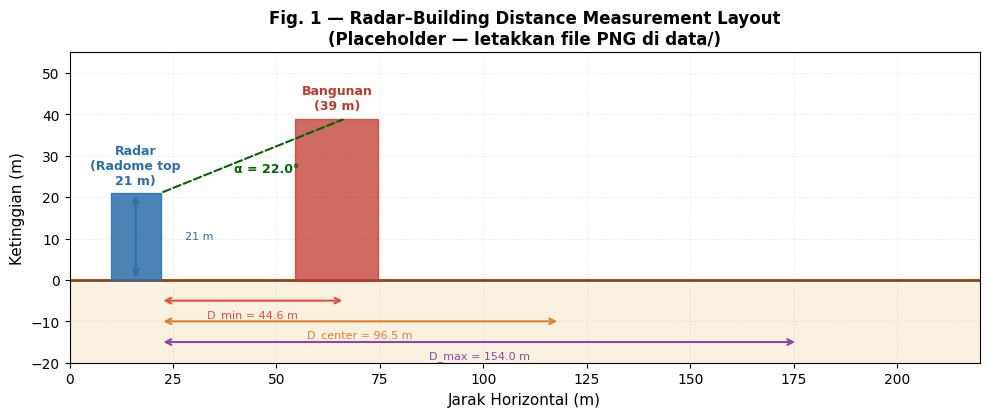

[OK] outputs/figures/fig1_measurement_layout.png


In [3]:
# ============================================================
# CELL 3 — Fig 1: Measurement Layout (dari data/ atau placeholder)
# ============================================================

fig1_path = "outputs/figures/fig1_measurement_layout.png"
src_img   = "data/Radar_Building_Distance_Measurement_Layout.png"

if os.path.exists(src_img):
    from matplotlib.image import imread
    img = imread(src_img)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title("Fig. 1 — Radar-Building Distance Measurement Layout\n"
                 "(Tangerang Geophysics Station, Google Earth Pro)",
                 fontsize=12, fontweight="bold", pad=10)
    plt.tight_layout()
    plt.savefig(fig1_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"[OK] {fig1_path}")
else:
    # ── Placeholder diagram layout ─────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_xlim(0, 300); ax.set_ylim(-20, 60)
    ax.set_aspect("equal")

    # Tanah
    ax.axhline(0, color="saddlebrown", lw=2, ls="-")
    ax.fill_between([0, 300], -20, 0, color="wheat", alpha=0.4)

    # Radar tower
    ax.add_patch(plt.Rectangle((10, 0), 12, H_RADAR,
                                color="#2C6FAC", alpha=0.85, zorder=3))
    ax.text(16, H_RADAR + 1.5, "Radar\n(Radome top\n21 m)",
            ha="center", va="bottom", fontsize=9, color="#2C6FAC",
            fontweight="bold")
    ax.annotate("", xy=(16, H_RADAR), xytext=(16, 0),
                arrowprops=dict(arrowstyle="<->", color="#2C6FAC", lw=1.5))
    ax.text(28, H_RADAR / 2, "21 m", va="center", fontsize=8,
            color="#2C6FAC")

    # Bangunan
    bldg_x = 44.6 + 10  # offset karena radar mulai x=10
    ax.add_patch(plt.Rectangle((bldg_x, 0), 20, H_BUILDING,
                                color="#C0392B", alpha=0.75, zorder=3))
    ax.text(bldg_x + 10, H_BUILDING + 1.5,
            f"Bangunan\n(39 m)",
            ha="center", va="bottom", fontsize=9, color="#C0392B",
            fontweight="bold")

    # Garis jarak D_min, D_center, D_max
    radar_tip_x = 22
    colors_d  = ["#E74C3C", "#E67E22", "#8E44AD"]
    labels_d  = [f"D_min = {D_MIN} m", f"D_center = {D_CENTER} m",
                 f"D_max = {D_MAX} m"]
    ys        = [-5, -10, -15]
    for d, lbl, yy, col in zip([D_MIN, D_CENTER, D_MAX],
                                labels_d, ys, colors_d):
        ax.annotate("", xy=(radar_tip_x + d, yy),
                    xytext=(radar_tip_x, yy),
                    arrowprops=dict(arrowstyle="<->", color=col, lw=1.5))
        ax.text(radar_tip_x + d / 2, yy - 2, lbl,
                ha="center", va="top", fontsize=8, color=col)

    # Sudut halangan untuk D_min
    alpha_min = alpha_values["D_min (44.6 m)"]
    x_end = radar_tip_x + D_MIN
    y_end = H_BUILDING
    ax.annotate("", xy=(x_end, y_end), xytext=(radar_tip_x, H_RADAR),
                arrowprops=dict(arrowstyle="-", color="darkgreen",
                                lw=1.5, ls="--"))
    ax.text(radar_tip_x + D_MIN * 0.4, H_RADAR + 5,
            f"α = {alpha_min:.1f}°", fontsize=9, color="darkgreen",
            fontweight="bold")

    ax.set_xlabel("Jarak Horizontal (m)", fontsize=11)
    ax.set_ylabel("Ketinggian (m)", fontsize=11)
    ax.set_title("Fig. 1 — Radar–Building Distance Measurement Layout\n"
                 "(Placeholder — letakkan file PNG di data/)",
                 fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3, ls=":")
    ax.set_xlim(0, 220)
    ax.set_ylim(-20, 55)

    plt.tight_layout()
    plt.savefig(fig1_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"[OK] {fig1_path}")


## Figure 2 — Side View: Obstruction Angle vs Beam Envelope

Tampilan samping (side view) yang memperlihatkan:
- Ketinggian radar dan bangunan
- Garis sudut halangan (α) untuk 3 skenario jarak  
- Amplop beam (lower–upper) untuk setiap elevasi


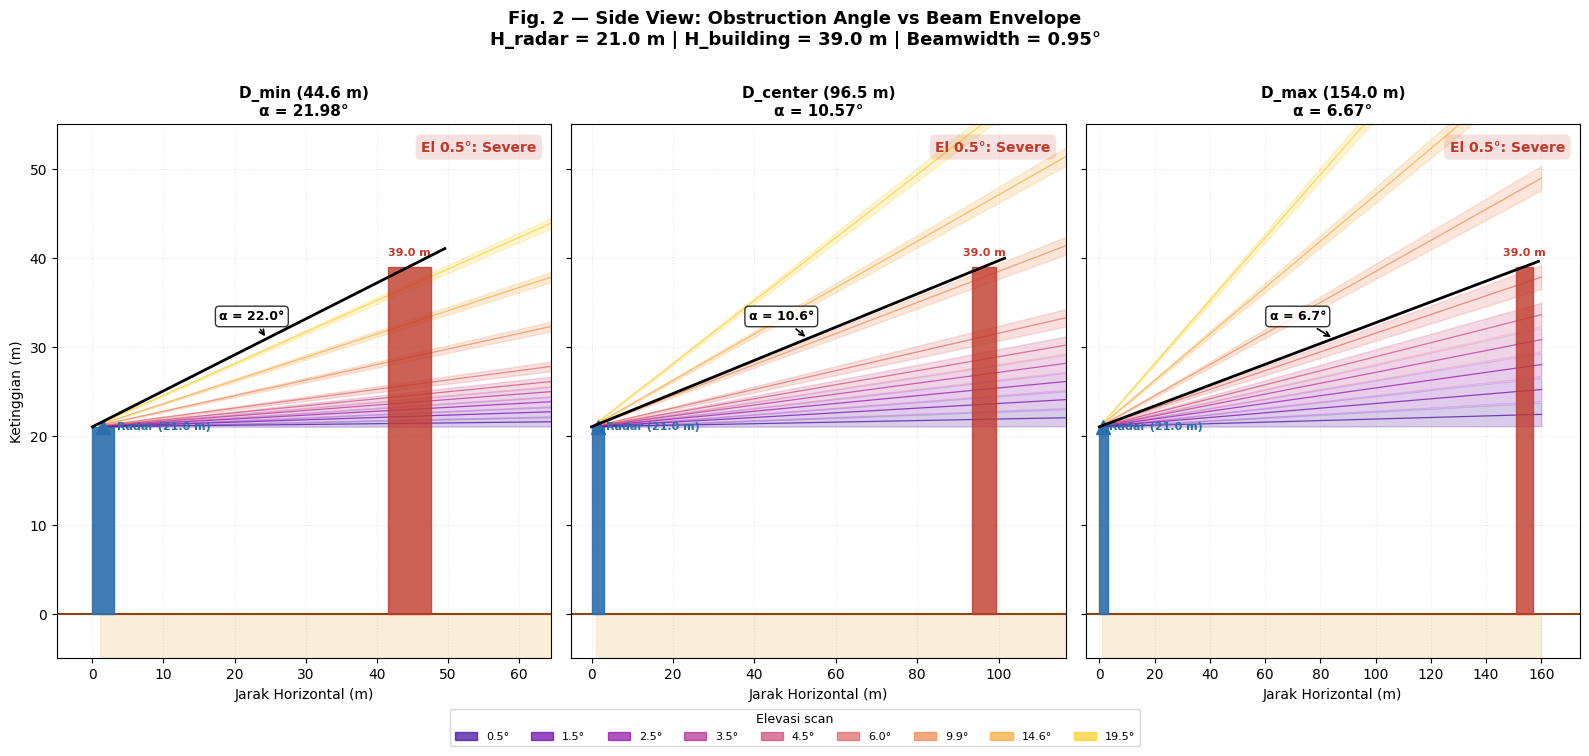

[OK] outputs/figures/fig2_side_view_obstruction.png


In [4]:
# ============================================================
# CELL 4 — Fig 2: Side View Obstruction Angle vs Beam Envelope
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 7), sharey=True)
fig.suptitle("Fig. 2 — Side View: Obstruction Angle vs Beam Envelope\n"
             f"H_radar = {H_RADAR} m | H_building = {H_BUILDING} m | "
             f"Beamwidth = {BEAMWIDTH}°",
             fontsize=13, fontweight="bold", y=1.01)

colors_elev = plt.cm.plasma(np.linspace(0.1, 0.9, len(ELEVATION_ANGLES)))
D_range     = np.linspace(1, 160, 400)  # m

for ax, (label, dist) in zip(axes, DISTANCES.items()):
    alpha = obstruction_angle(H_BUILDING, H_RADAR, dist)

    # ── Ground ──────────────────────────────────────────────────────────────
    ax.axhline(0, color="saddlebrown", lw=1.5)
    ax.fill_between(D_range, -5, 0, color="wheat", alpha=0.5)

    # ── Beam envelopes untuk setiap elevasi ──────────────────────────────────
    for i, elev in enumerate(ELEVATION_ANGLES):
        tl = beam_lower(elev, BEAMWIDTH)
        tu = beam_upper(elev, BEAMWIDTH)
        # Ketinggian upper/lower edge pada jarak D_range
        h_lower = H_RADAR + D_range * np.tan(np.radians(tl))
        h_upper = H_RADAR + D_range * np.tan(np.radians(tu))
        ax.fill_between(D_range, h_lower, h_upper,
                        alpha=0.20, color=colors_elev[i])
        ax.plot(D_range, H_RADAR + D_range * np.tan(np.radians(elev)),
                color=colors_elev[i], lw=0.9, alpha=0.7,
                label=f"{elev}°")

    # ── Radar (tower) ────────────────────────────────────────────────────────
    ax.add_patch(plt.Rectangle((0, 0), 3, H_RADAR,
                                color="#2C6FAC", alpha=0.9, zorder=5))
    ax.plot(1.5, H_RADAR, "^", color="#2C6FAC", ms=10, zorder=6)
    ax.text(3.5, H_RADAR, f"Radar ({H_RADAR} m)",
            va="center", fontsize=8, color="#2C6FAC", fontweight="bold")

    # ── Bangunan ─────────────────────────────────────────────────────────────
    bldg_w = 6
    ax.add_patch(plt.Rectangle((dist - bldg_w/2, 0), bldg_w, H_BUILDING,
                                color="#C0392B", alpha=0.80, zorder=5))
    ax.text(dist, H_BUILDING + 1,
            f"{H_BUILDING} m", ha="center", va="bottom",
            fontsize=8, color="#C0392B", fontweight="bold")

    # ── Garis sudut halangan α ───────────────────────────────────────────────
    x_obs = np.linspace(0, dist + 5, 200)
    y_obs = H_RADAR + x_obs * np.tan(np.radians(alpha))
    ax.plot(x_obs, y_obs, color="black", lw=2.0, ls="-",
            zorder=7, label=f"α = {alpha:.1f}°")

    # Anotasi sudut α
    ax.annotate(f"α = {alpha:.1f}°",
                xy=(dist * 0.55, H_RADAR + dist * 0.55 *
                    np.tan(np.radians(alpha))),
                xytext=(dist * 0.4, H_RADAR + 12),
                fontsize=9, fontweight="bold", color="black",
                arrowprops=dict(arrowstyle="->", color="black", lw=1.2),
                bbox=dict(boxstyle="round,pad=0.3", fc="white",
                          ec="black", alpha=0.8))

    # ── Klasifikasi worst-case (elevasi terendah) ────────────────────────────
    tl0 = beam_lower(ELEVATION_ANGLES[0], BEAMWIDTH)
    tu0 = beam_upper(ELEVATION_ANGLES[0], BEAMWIDTH)
    cl0 = classify_blockage(alpha, tl0, tu0)
    cl_colors = {"Clear": "#27AE60", "Partial": "#F39C12", "Severe": "#C0392B"}
    ax.text(0.97, 0.97, f"El 0.5°: {cl0}",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=10, fontweight="bold", color=cl_colors[cl0],
            bbox=dict(boxstyle="round,pad=0.4",
                      fc=cl_colors[cl0], ec="none", alpha=0.15))

    ax.set_title(f"{label}\nα = {alpha:.2f}°",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Jarak Horizontal (m)", fontsize=10)
    ax.set_xlim(-5, dist + 20)
    ax.set_ylim(-5, 55)
    ax.grid(True, alpha=0.3, ls=":")
    ax.set_ylabel("Ketinggian (m)" if ax == axes[0] else "", fontsize=10)

# Legend elevasi
handles = [mpatches.Patch(color=colors_elev[i], alpha=0.7,
                           label=f"{e}°")
           for i, e in enumerate(ELEVATION_ANGLES)]
fig.legend(handles=handles, title="Elevasi scan", fontsize=8,
           title_fontsize=9, ncol=9, loc="lower center",
           bbox_to_anchor=(0.5, -0.05), frameon=True)

plt.tight_layout()
fig2_path = "outputs/figures/fig2_side_view_obstruction.png"
plt.savefig(fig2_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"[OK] {fig2_path}")


## Figure 3 — Classification Heatmap

Heatmap klasifikasi blockage untuk semua kombinasi **elevasi × skenario jarak**.


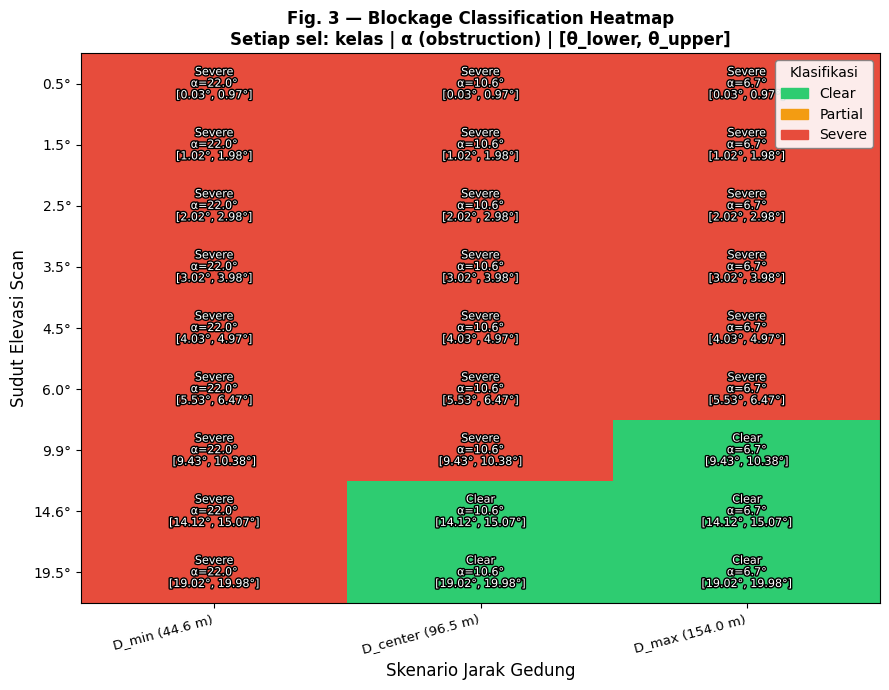

[OK] outputs/figures/fig3_classification_heatmap.png


In [5]:
# ============================================================
# CELL 5 — Fig 3: Classification Heatmap
# ============================================================

from matplotlib.colors import ListedColormap, BoundaryNorm

# Encode klasifikasi ke angka
encode  = {"Clear": 0, "Partial": 1, "Severe": 2}
decode  = {0: "Clear", 1: "Partial", 2: "Severe"}
cl_cmap = ListedColormap(["#2ECC71", "#F39C12", "#E74C3C"])  # hijau, oranye, merah
cl_norm = BoundaryNorm([0, 1, 2, 3], cl_cmap.N)

# Matrix: baris = elevasi, kolom = skenario jarak
matrix = np.zeros((len(ELEVATION_ANGLES), len(DISTANCES)), dtype=int)
alpha_row = []

for j, (label, dist) in enumerate(DISTANCES.items()):
    alpha = obstruction_angle(H_BUILDING, H_RADAR, dist)
    alpha_row.append(alpha)
    for i, elev in enumerate(ELEVATION_ANGLES):
        tl = beam_lower(elev, BEAMWIDTH)
        tu = beam_upper(elev, BEAMWIDTH)
        matrix[i, j] = encode[classify_blockage(alpha, tl, tu)]

fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(matrix, cmap=cl_cmap, norm=cl_norm,
               aspect="auto", interpolation="nearest")

# Teks di setiap sel
for i in range(len(ELEVATION_ANGLES)):
    for j in range(len(DISTANCES)):
        val  = decode[matrix[i, j]]
        elev = ELEVATION_ANGLES[i]
        tl   = beam_lower(elev, BEAMWIDTH)
        tu   = beam_upper(elev, BEAMWIDTH)
        al   = alpha_row[j]
        txt  = f"{val}\nα={al:.1f}°\n[{tl:.2f}°, {tu:.2f}°]"
        ax.text(j, i, txt, ha="center", va="center",
                fontsize=8, color="white",
                path_effects=[pe.withStroke(linewidth=2,
                                            foreground="black")])

ax.set_xticks(range(len(DISTANCES)))
ax.set_xticklabels(list(DISTANCES.keys()), fontsize=9.5,
                   rotation=15, ha="right")
ax.set_yticks(range(len(ELEVATION_ANGLES)))
ax.set_yticklabels([f"{e}°" for e in ELEVATION_ANGLES], fontsize=10)
ax.set_xlabel("Skenario Jarak Gedung", fontsize=12)
ax.set_ylabel("Sudut Elevasi Scan", fontsize=12)
ax.set_title("Fig. 3 — Blockage Classification Heatmap\n"
             "Setiap sel: kelas | α (obstruction) | [θ_lower, θ_upper]",
             fontsize=12, fontweight="bold")

# Colorbar / legend
patches = [mpatches.Patch(color=c, label=l)
           for c, l in zip(["#2ECC71","#F39C12","#E74C3C"],
                           ["Clear","Partial","Severe"])]
ax.legend(handles=patches, fontsize=10, loc="upper right",
          title="Klasifikasi", title_fontsize=10,
          framealpha=0.9, edgecolor="gray")

plt.tight_layout()
fig3_path = "outputs/figures/fig3_classification_heatmap.png"
plt.savefig(fig3_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"[OK] {fig3_path}")


## Figure 4 — Obstruction Angle vs Distance

Kurva sudut halangan α(d) sebagai fungsi jarak kontinu, dengan garis beam lower/upper
untuk setiap elevasi sebagai referensi.


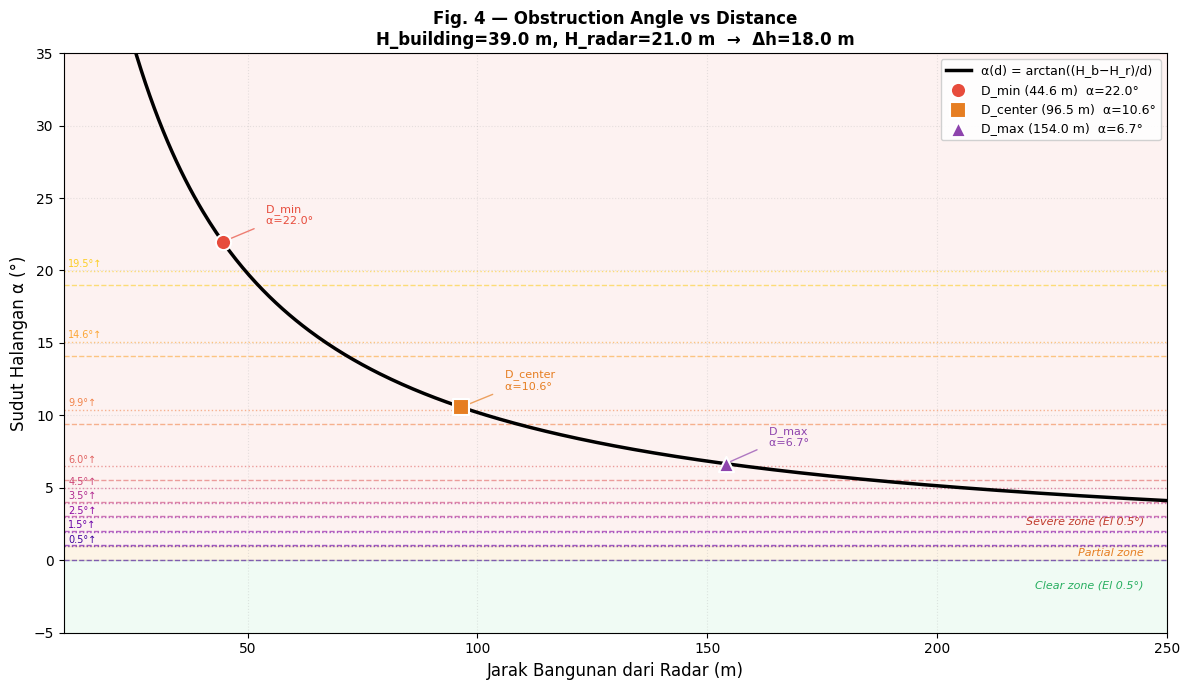

[OK] outputs/figures/fig4_obstruction_angle_vs_distance.png


In [6]:
# ============================================================
# CELL 6 — Fig 4: Obstruction Angle vs Distance (continuous)
# ============================================================

d_cont = np.linspace(10, 250, 500)  # m
alpha_cont = obstruction_angle(H_BUILDING, H_RADAR, d_cont)

fig, ax = plt.subplots(figsize=(12, 7))

# ── Background: zona Severe / Partial / Clear ────────────────────────────────
# Berdasarkan elevasi terendah 0.5°
tl_ref = beam_lower(ELEVATION_ANGLES[0], BEAMWIDTH)
tu_ref = beam_upper(ELEVATION_ANGLES[0], BEAMWIDTH)
ax.axhspan(tu_ref, 35,  color="#E74C3C", alpha=0.07, label="_nolegend_")
ax.axhspan(tl_ref, tu_ref, color="#F39C12", alpha=0.10, label="_nolegend_")
ax.axhspan(-10, tl_ref,    color="#2ECC71", alpha=0.07, label="_nolegend_")

# Teks zona (di sisi kanan)
ax.text(245, tu_ref + 1.5, "Severe zone (El 0.5°)", fontsize=8,
        color="#C0392B", ha="right", style="italic")
ax.text(245, (tl_ref + tu_ref) / 2, "Partial zone", fontsize=8,
        color="#E67E22", ha="right", va="center", style="italic")
ax.text(245, tl_ref - 2.0, "Clear zone (El 0.5°)", fontsize=8,
        color="#27AE60", ha="right", style="italic")

# ── Beam lower/upper untuk semua elevasi ────────────────────────────────────
cmap_el = plt.cm.plasma(np.linspace(0.1, 0.9, len(ELEVATION_ANGLES)))
for i, elev in enumerate(ELEVATION_ANGLES):
    tl = beam_lower(elev, BEAMWIDTH)
    tu = beam_upper(elev, BEAMWIDTH)
    ax.axhline(tl, color=cmap_el[i], lw=1.0, ls="--", alpha=0.6)
    ax.axhline(tu, color=cmap_el[i], lw=1.0, ls=":",  alpha=0.6)
    # Label di kiri
    ax.text(11, tu + 0.1, f"{elev}°↑", fontsize=7, color=cmap_el[i],
            va="bottom")

# ── Kurva α(d) ───────────────────────────────────────────────────────────────
ax.plot(d_cont, alpha_cont, "k-", lw=2.5, zorder=6,
        label=f"α(d) = arctan((H_b−H_r)/d)")

# ── Marker 3 skenario jarak ──────────────────────────────────────────────────
marker_styles = ["o", "s", "^"]
m_colors      = ["#E74C3C", "#E67E22", "#8E44AD"]
for (label, dist), mk, mc in zip(DISTANCES.items(),
                                  marker_styles, m_colors):
    al = obstruction_angle(H_BUILDING, H_RADAR, dist)
    ax.scatter(dist, al, s=120, color=mc, marker=mk, zorder=8,
               edgecolors="white", linewidths=1.5,
               label=f"{label}  α={al:.1f}°")
    ax.annotate(f"  {label.split()[0]}\n  α={al:.1f}°",
                xy=(dist, al), xytext=(dist + 8, al + 1.2),
                fontsize=8, color=mc,
                arrowprops=dict(arrowstyle="-", color=mc,
                                lw=1, alpha=0.7))

ax.set_xlabel("Jarak Bangunan dari Radar (m)", fontsize=12)
ax.set_ylabel("Sudut Halangan α (°)", fontsize=12)
ax.set_title(f"Fig. 4 — Obstruction Angle vs Distance\n"
             f"H_building={H_BUILDING} m, H_radar={H_RADAR} m  "
             f"→  Δh={H_BUILDING-H_RADAR} m",
             fontsize=12, fontweight="bold")

ax.set_xlim(10, 250)
ax.set_ylim(-5, 35)
ax.grid(True, alpha=0.3, ls=":")
ax.legend(fontsize=9, loc="upper right", framealpha=0.9)

plt.tight_layout()
fig4_path = "outputs/figures/fig4_obstruction_angle_vs_distance.png"
plt.savefig(fig4_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"[OK] {fig4_path}")


## Figure 5 — Polar Sector View

Diagram kutub yang menunjukkan sektor azimuth yang berpotensi terblokir
beserta zona jarak gedung (D_min–D_max) pada tampilan plan view.


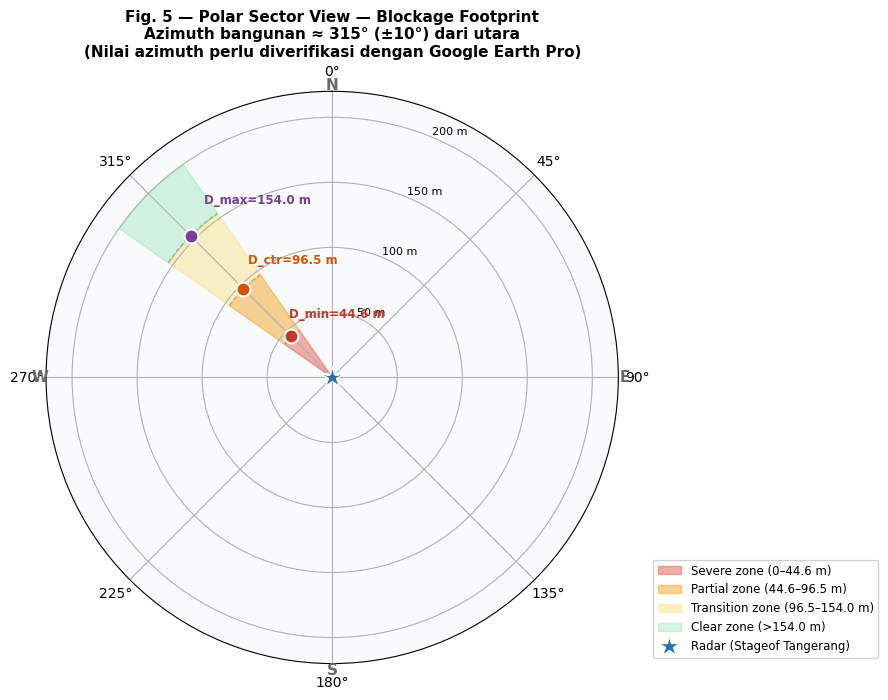

[OK] outputs/figures/fig5_polar_sector.png


In [7]:
# ============================================================
# CELL 7 — Fig 5: Polar Sector View (Plan View / PPI-style)
# ============================================================

# Asumsi geometri azimuth bangunan terhadap radar
# (Nilai ini harus diisi dari data Google Earth — gunakan nilai dummy 315° = NW)
AZIMUTH_CENTER = 315.0   # derajat dari North, searah jarum jam
AZIMUTH_SPREAD =  20.0   # spread ±10° dari pusat (footprint bangunan)
AZ_MIN = AZIMUTH_CENTER - AZIMUTH_SPREAD / 2
AZ_MAX = AZIMUTH_CENTER + AZIMUTH_SPREAD / 2

fig, ax = plt.subplots(figsize=(9, 9),
                        subplot_kw={"projection": "polar"})

# ── Radar di tengah ──────────────────────────────────────────────────────────
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)   # clockwise seperti konvensi azimuth

# Range rings
max_r = 200  # m (skala lokal sekitar radar)
rticks = [50, 100, 150, 200]
ax.set_rticks(rticks)
ax.set_yticklabels([f"{r} m" for r in rticks], fontsize=8)
ax.set_rlim(0, max_r + 20)

# ── Isi background ───────────────────────────────────────────────────────────
theta_all = np.linspace(0, 2 * np.pi, 360)
ax.fill(theta_all, np.full_like(theta_all, max_r + 20),
        color="#F0F4F8", alpha=0.4, zorder=0)

# ── Sektor blockage (AZ_MIN → AZ_MAX) ───────────────────────────────────────
az_sector = np.linspace(np.radians(AZ_MIN), np.radians(AZ_MAX), 60)

# Zona Severe   (D_min): r = 0 → D_min
ax.fill_between(az_sector, 0, D_MIN,
                color="#E74C3C", alpha=0.45,
                label=f"Severe zone (0–{D_MIN} m)")

# Zona Partial  (D_min → D_center)
ax.fill_between(az_sector, D_MIN, D_CENTER,
                color="#F39C12", alpha=0.45,
                label=f"Partial zone ({D_MIN}–{D_CENTER} m)")

# Zona Transisi (D_center → D_max)
ax.fill_between(az_sector, D_CENTER, D_MAX,
                color="#F7DC6F", alpha=0.40,
                label=f"Transition zone ({D_CENTER}–{D_MAX} m)")

# Zona Clear    (D_max → max_r)
ax.fill_between(az_sector, D_MAX, max_r,
                color="#2ECC71", alpha=0.20,
                label=f"Clear zone (>{D_MAX} m)")

# ── Garis jarak kunci ────────────────────────────────────────────────────────
az_mid = np.radians(AZIMUTH_CENTER)
for d, lbl, col in [(D_MIN, "D_min", "#C0392B"),
                     (D_CENTER, "D_ctr", "#D35400"),
                     (D_MAX, "D_max", "#7D3C98")]:
    ax.plot([az_mid], [d], "o", color=col, ms=10, zorder=8,
            markeredgecolor="white", markeredgewidth=1.5)
    ax.annotate(f"{lbl}={d} m", xy=(az_mid, d),
                xytext=(az_mid + 0.15, d + 12),
                fontsize=8.5, color=col, fontweight="bold")

# ── Arc garis sektor ─────────────────────────────────────────────────────────
for r_arc in [D_MIN, D_CENTER, D_MAX]:
    ax.plot(az_sector, np.full_like(az_sector, r_arc),
            "--", color="gray", lw=0.9, alpha=0.6)

# ── Label arah ───────────────────────────────────────────────────────────────
for deg, lbl in [(0,"N"), (90,"E"), (180,"S"), (270,"W")]:
    ax.text(np.radians(deg), max_r + 25, lbl,
            ha="center", va="center", fontsize=11,
            fontweight="bold", color="dimgray")

# ── Radar marker ─────────────────────────────────────────────────────────────
ax.plot(0, 0, "*", ms=16, color="#2C6FAC", zorder=10,
        markeredgecolor="white", markeredgewidth=1,
        label="Radar (Stageof Tangerang)")

ax.set_title(f"Fig. 5 — Polar Sector View — Blockage Footprint\n"
             f"Azimuth bangunan ≈ {AZIMUTH_CENTER:.0f}° "
             f"(±{AZIMUTH_SPREAD/2:.0f}°) dari utara\n"
             f"(Nilai azimuth perlu diverifikasi dengan Google Earth Pro)",
             fontsize=11, fontweight="bold", pad=25)
ax.legend(fontsize=8.5, loc="lower left",
          bbox_to_anchor=(1.05, 0.0), framealpha=0.9)

plt.tight_layout()
fig5_path = "outputs/figures/fig5_polar_sector.png"
plt.savefig(fig5_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"[OK] {fig5_path}")


## Ringkasan Hasil & Interpretasi


In [8]:
# ============================================================
# CELL 8 — Ringkasan Hasil Kuantitatif
# ============================================================

print("=" * 65)
print("  RINGKASAN HASIL — Geometry-Based Beam Blockage Assessment")
print("=" * 65)
print(f"  Radar : {H_RADAR} m (top-of-radome)  |  "
      f"Bangunan: {H_BUILDING} m  |  Δh = {H_BUILDING - H_RADAR} m")
print(f"  Beam width: {BEAMWIDTH}°")
print()

for label, dist in DISTANCES.items():
    alpha = obstruction_angle(H_BUILDING, H_RADAR, dist)
    print(f"  ─── {label} ───")
    print(f"    Sudut halangan α = {alpha:.3f}°")
    print(f"    {'Elevasi':>8s}  {'θ_lower':>8s}  {'θ_upper':>8s}  "
          f"{'α vs beam':>14s}  {'Klasifikasi'}")
    print(f"    {'(°)':>8s}  {'(°)':>8s}  {'(°)':>8s}  "
          f"{'':>14s}  ")
    print("    " + "-" * 58)
    for elev in ELEVATION_ANGLES:
        tl = beam_lower(elev, BEAMWIDTH)
        tu = beam_upper(elev, BEAMWIDTH)
        cl = classify_blockage(alpha, tl, tu)
        emoji = {"Clear":"🟢","Partial":"🟡","Severe":"🔴"}[cl]
        rel = (f"α > θ_upper (+{alpha-tu:.2f}°)" if cl == "Severe"
               else f"α < θ_lower ({alpha-tl:.2f}°)" if cl == "Clear"
               else f"θ_l ≤ α ≤ θ_u")
        print(f"    {elev:>8.1f}  {tl:>8.3f}  {tu:>8.3f}  "
              f"{rel:>22s}  {emoji} {cl}")
    print()

print()
print("  Output files:")
print("    outputs/tables/blockage_classification.csv")
for fn in ["fig1_measurement_layout.png", "fig2_side_view_obstruction.png",
           "fig3_classification_heatmap.png",
           "fig4_obstruction_angle_vs_distance.png",
           "fig5_polar_sector.png"]:
    exists = "✓" if os.path.exists(f"outputs/figures/{fn}") else "✗"
    print(f"    {exists} outputs/figures/{fn}")
print("=" * 65)


  RINGKASAN HASIL — Geometry-Based Beam Blockage Assessment
  Radar : 21.0 m (top-of-radome)  |  Bangunan: 39.0 m  |  Δh = 18.0 m
  Beam width: 0.95°

  ─── D_min (44.6 m) ───
    Sudut halangan α = 21.978°
     Elevasi   θ_lower   θ_upper       α vs beam  Klasifikasi
         (°)       (°)       (°)                  
    ----------------------------------------------------------
         0.5     0.025     0.975   α > θ_upper (+21.00°)  🔴 Severe
         1.5     1.025     1.975   α > θ_upper (+20.00°)  🔴 Severe
         2.5     2.025     2.975   α > θ_upper (+19.00°)  🔴 Severe
         3.5     3.025     3.975   α > θ_upper (+18.00°)  🔴 Severe
         4.5     4.025     4.975   α > θ_upper (+17.00°)  🔴 Severe
         6.0     5.525     6.475   α > θ_upper (+15.50°)  🔴 Severe
         9.9     9.425    10.375   α > θ_upper (+11.60°)  🔴 Severe
        14.6    14.125    15.075    α > θ_upper (+6.90°)  🔴 Severe
        19.5    19.025    19.975    α > θ_upper (+2.00°)  🔴 Severe

  ─── D_cente

## Catatan untuk Paper

### Kutipan metode yang disarankan

> *"The obstruction angle was calculated as α = arctan((H_b − H_r) / d), where H_b is the building height (39 m), H_r is the radar top-of-radome height (21 m), and d is the horizontal distance. Beam blockage classification followed a geometric criterion: Clear if α < θ − β/2, Severe if α > θ + β/2, and Partial otherwise, where θ is the nominal scan elevation and β = 0.95° is the −3 dB beamwidth (EEC datasheet)."*

### Batasan yang harus disebutkan di paper

1. Analisis ini adalah **asesmen geometri preliminer**, bukan kalkulasi fraksi PBB berbasis DEM.
2. Tinggi radar mengacu pada **top-of-radome (21 m)**, bukan pusat fase antena — sehingga α sedikit *underestimated*.
3. Sudut elevasi adalah referensi **VCP 21-style**, bukan konfirmasi moda scan operasional Tangerang.
4. Azimuth bangunan (Fig. 5) menggunakan **nilai asumsi (315°)** — harus diverifikasi dari data Google Earth Pro (Tim Putri/Pak Sidik).

### Rekomendasi lanjutan

- Gunakan `wradlib.qual.beam_block_frac()` untuk kalkulasi fraksi PBB berbasis DEM SRTM (lihat `tangerang_beam_blockage_assessment.py`).
- Dapatkan konfirmasi sudut elevasi operasional dari operator BMKG/Stageof.
- Update `AZIMUTH_CENTER` dan `AZIMUTH_SPREAD` di Cell 7 setelah verifikasi Google Earth.
